Universidade do Vale do Itajaí  
Processamento Digital de Sinais  
Docente: Walter Antônio Gotijo  
Acadêmico: Henry José  
Curso: Engenharia de Computação 8º Semestre  


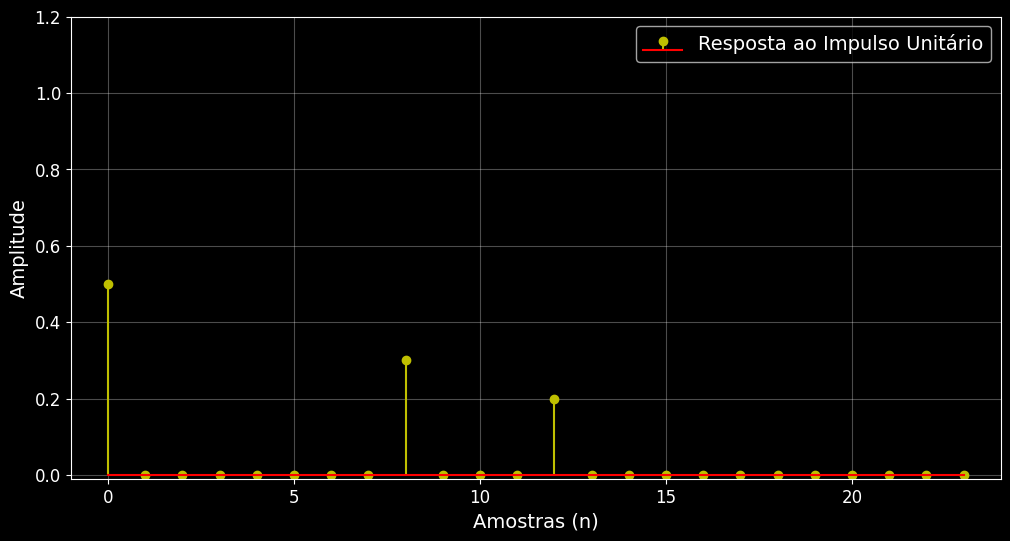

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from IPython.display import Audio

Fs = 8000
t1 = 1e-3
t2 = 1.5e-3

# Converte para INTEIRO (int) para usar como índice/tamanho
n1 = int(t1 * Fs)  # 8 amostras
n2 = int(t2 * Fs)  # 12 amostras

# Definição dos ganhos
a0 = 0.5
a1 = 0.3
a2 = 0.2

tama_delay = n2
# O tamanho do buffer de delay precisa cobrir de 0 até n2 (tamanho n2 + 1)
vetor_delay = np.zeros(tama_delay + 1)

# Definição da entrada
entrada = np.zeros(2 * tama_delay)
entrada[0] = 1  # Impulso unitário no primeiro elemento (índice 0)

tama_loop = len(entrada)
vet_saida = np.zeros(tama_loop)
n = list(range(tama_loop))

# Loop de processamento
for j in range(tama_loop):
    inp = entrada[j]
    vetor_delay[0] = inp
    
    # Cálculo da saída da equação de diferenças
    y = a0 * vetor_delay[0] + a1 * vetor_delay[n1] + a2 * vetor_delay[n2]
    
    # Desloca o vetor de delay (equivale ao deslocamento dos registradores)
    vetor_delay[1:] = vetor_delay[:-1]
    
    vet_saida[j] = y

# Plotagem do gráfico
plt.figure(figsize=(12, 6))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

plt.stem(n, vet_saida, linefmt='y-', markerfmt='yo', basefmt='r-', label='Resposta ao Impulso Unitário')
plt.ylim(-0.01, 1.2)
plt.xlim(-1, tama_loop)
plt.xlabel('Amostras (n)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

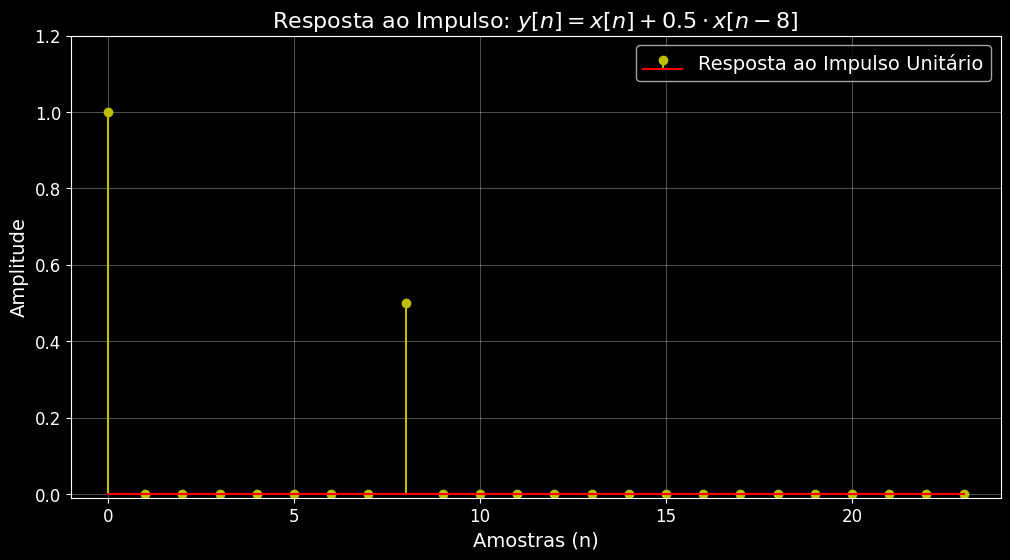

In [19]:
# Parâmetros do sistema
Fs = 8000           # Taxa de amostragem: 8 kHz (Ts = 125 us)
t1 = 1e-3           # Atraso: 1 ms

# Cálculo do atraso em amostras
D = int(t1 * Fs)    # D = 8 amostras

# Definição dos ganhos
a0 = 1.0
a1 = 0.5

# O buffer de delay precisa armazenar de x[n] (índice 0) até x[n-D] (índice D)
# Portanto, necessita de tamanho D + 1 (9 elementos)
vetor_delay = np.zeros(D + 1)

# Definição do sinal de entrada (Impulso Unitário delta[n])
N_amostras = 24     # Tamanho da simulação (suficiente para visualizar o efeito)
entrada = np.zeros(N_amostras)
entrada[0] = 1.0    # Impulso unitário no instante n = 0

tama_loop = len(entrada)
vet_saida = np.zeros(tama_loop)
n = list(range(tama_loop))

# Loop de processamento (Filtro FIR com atraso D)
for j in range(tama_loop):
    inp = entrada[j]
    
    # Atualiza a entrada atual no início do buffer
    vetor_delay[0] = inp
    
    # Equação de diferenças: y[n] = a0 * x[n] + a1 * x[n - D]
    # No buffer: vetor_delay[0] é x[n] e vetor_delay[D] é x[n-D]
    y = a0 * vetor_delay[0] + a1 * vetor_delay[D]
    
    # Salva a saída calculada
    vet_saida[j] = y
    
    # Desloca os valores no buffer de atraso para o próximo passo de tempo
    vetor_delay[1:] = vetor_delay[:-1]

# Plotagem do gráfico
plt.figure(figsize=(12, 6))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

plt.stem(n, vet_saida, linefmt='y-', markerfmt='yo', basefmt='r-', label='Resposta ao Impulso Unitário')
plt.ylim(-0.01, 1.2)
plt.xlim(-1, tama_loop)
plt.xlabel('Amostras (n)', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.title('Resposta ao Impulso: $y[n] = x[n] + 0.5 \\cdot x[n-8]$', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
import numpy as np

Fs = 16000
audio_array = np.fromfile("Gravando.pcm", dtype=np.int16).astype(np.float32)

atraso_s = 0.125  # 100 ms
D = int(atraso_s * Fs)  # 1600 amostras

a0 = 1.0
a1 = 0.1

tama_loop = len(audio_array)
vet_saida = np.zeros(tama_loop, dtype=np.float32)

# Buffer de tamanho D + 1 para armazenar x[n] até x[n-D]
vetor_delay = np.zeros(D + 1, dtype=np.float32)

for j in range(tama_loop):
    inp = audio_array[j]

    # Atualiza a amostra atual x[n] no buffer
    vetor_delay[0] = inp

    # Equação de diferenças (FIR): y[n] = a0 * x[n] + a1 * x[n-D]
    y = a0 * vetor_delay[0] + a1 * vetor_delay[D]

    vet_saida[j] = y

    # Desloca o buffer para o próximo instante k
    vetor_delay[1:] = vetor_delay[:-1]

# Prevenção de clipping e salvamento
max_val = np.max(np.abs(vet_saida))
if max_val > 32767:
    vet_saida = (vet_saida / max_val) * 32767

vet_saida.astype(np.int16).tofile("Gravando_com_eco.pcm")
Eco = np.fromfile("Gravando_com_eco.pcm", dtype=np.int16)
Audio(Eco,rate=Fs)

Resultado com np.convolve: [1.    1.5   1.75  1.875 1.875 1.875 0.875 0.375 0.125]


<function matplotlib.pyplot.show(close=None, block=None)>

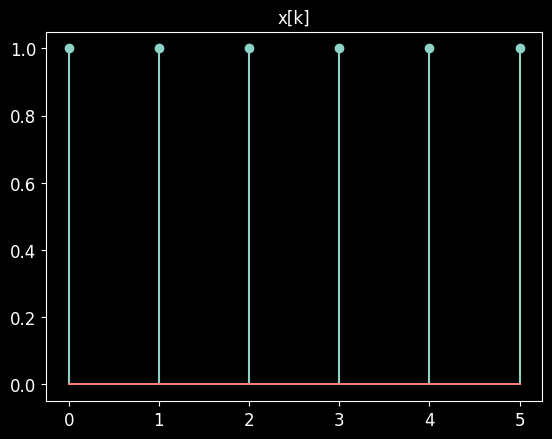

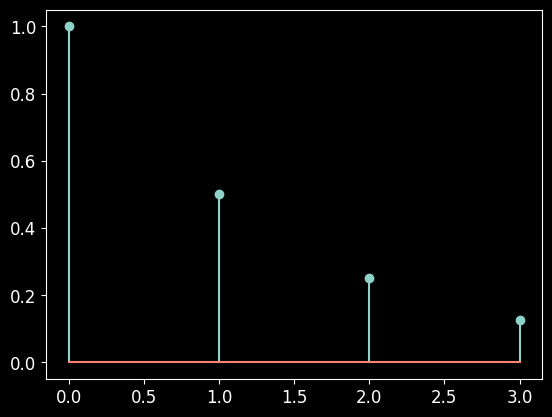

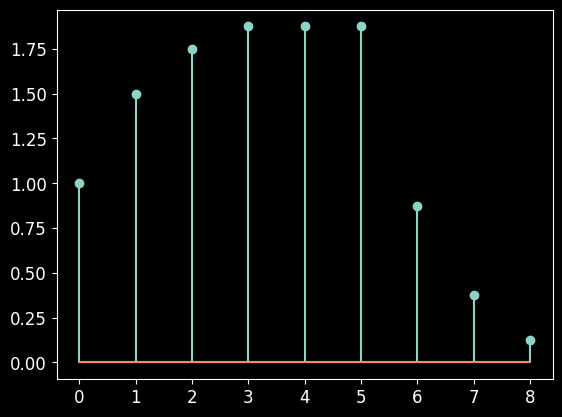

In [27]:
x = np.array([1,1,1,1,1,1])
h = np.array([1,0.5,0.25,0.125])
h_len = np.arange(len(h))
x_len = np.arange(len(x))
# mode='full' gera a convolução completa com tamanho Nx + Nh - 1
y_numpy = np.convolve(x, h, mode='full')
n_y = np.arange(len(y_numpy))
print("Resultado com np.convolve:", y_numpy)


plt.figure()
plt.stem(x_len,x)
plt.title("x[k]")
plt.show

plt.figure()
plt.stem(h_len,h)
plt.show

plt.figure()
plt.stem(n_y,y_numpy)
plt.show
